In [11]:
from sbcasdiego.Datasets.DefaultDataset import DefaultDataset
import pandas as pd
from sklearn.preprocessing import LabelEncoder
%matplotlib inline
import matplotlib.pyplot as plt


In [12]:
df = pd.read_csv("../datasets/compas-scores-raw.csv", sep=",")

In [13]:
df.drop_duplicates(inplace=True)

#remove columns with null values
df = df.dropna(axis=1)
# remove name and first and last
df = df.drop(columns=["name", "first", "last"])
print(df.size)

target = "is_recid"

le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == type(object):
        df[column] = le.fit_transform(df[column])


258654


In [14]:
df.head(10)

,id,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,...,c_charge_degree,is_recid,r_charge_degree,is_violent_recid,v_type_of_assessment,v_decile_score,v_screening_date,type_of_assessment,decile_score.1,screening_date
0,1,206,1,91,69,1,5,0,1,0,...,0,0,2,0,0,1,206,0,1,206
1,2,703,1,4776,31,0,2,0,5,0,...,2,-1,2,0,0,2,703,0,5,703
2,3,26,1,4079,34,0,0,0,3,0,...,0,1,0,1,0,1,26,0,3,26
3,4,103,1,6443,24,2,0,0,4,0,...,0,1,1,0,0,3,103,0,4,103
4,5,12,1,6910,23,2,0,0,8,1,...,0,0,2,0,0,6,12,0,8,12
5,6,84,1,2482,43,0,5,0,1,0,...,0,0,2,0,0,1,84,0,1,84
6,7,311,1,2247,44,0,5,0,1,0,...,1,0,2,0,0,1,311,0,1,311
7,8,392,1,2692,41,0,2,0,6,0,...,0,1,0,0,0,2,392,0,6,392
8,9,222,1,2494,43,0,5,0,4,0,...,0,0,2,0,0,3,222,0,4,222
9,10,417,0,2982,39,0,2,0,1,0,...,1,0,2,0,0,1,417,0,1,417


In [15]:
h = DefaultDataset(
    dataset= df,
    predicted_attr=target,
    protected_attr=None,
    protected_attr_mappings=None,
    positive_outcome=1
)
# h.num_repetitions = 1
# h.execute_models()

Max correlation: r_charge_degree (-0.833123649764889)


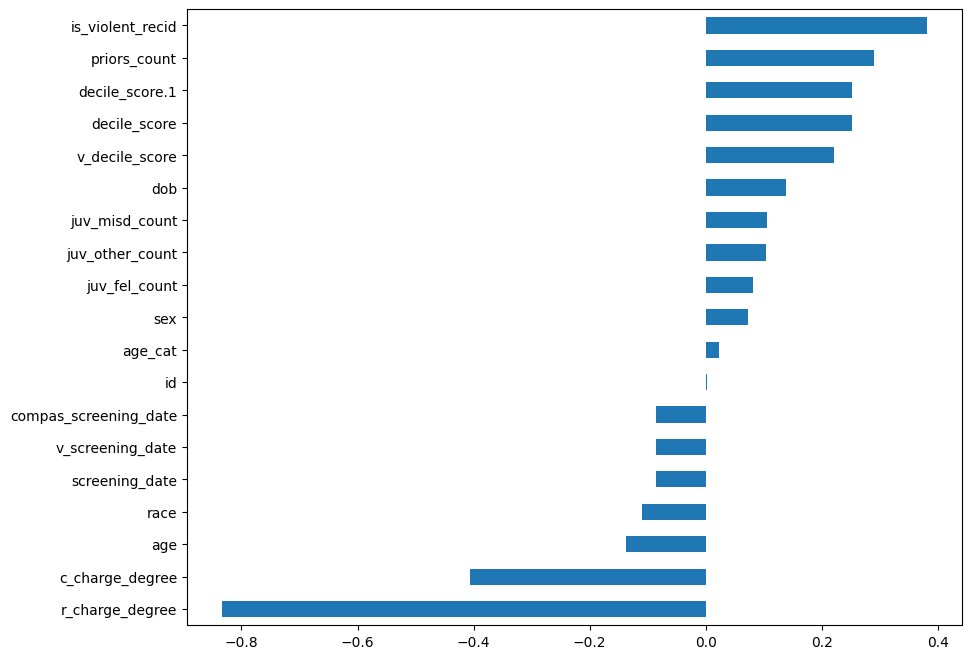

In [16]:
correlations = df.corr()[target].drop(target).dropna().sort_values()
correlations.plot(kind='barh', figsize=(10, 8))

max_corr = correlations.abs().idxmax()
print(f"Max correlation: {max_corr} ({correlations[max_corr]})")


In [17]:
protected_attr_mappings = {}
for column in df.columns:
    if df[column].nunique() == 2 and column != h.predicted_attr:
        protected_attr_mappings[column] = {"Privileged": df[column].value_counts().idxmax(), "Unprivileged": df[column].value_counts().idxmin()}
protected_attr_mappings

{'sex': {'Privileged': 1, 'Unprivileged': 0},
 'is_violent_recid': {'Privileged': 0, 'Unprivileged': 1}}

In [18]:
h.protected_attr_mappings = protected_attr_mappings
h.protected_attr = list(protected_attr_mappings.keys())
metrics = h.get_metrics(correlated_vars=max_corr,
    df_train=df)

/home/diego/git/SBCAS2025_Diego_PreTrainingBias/.venv/lib/python3.10/site-packages/sbcasdiego/PreTrainingBias/PreTrainingBias.py:16: RuntimeWarning: divide by zero encountered in log
  return np.sum(p * np.log(p / q))
/home/diego/git/SBCAS2025_Diego_PreTrainingBias/.venv/lib/python3.10/site-packages/sbcasdiego/PreTrainingBias/PreTrainingBias.py:16: RuntimeWarning: invalid value encountered in double_scalars
  return np.sum(p * np.log(p / q))


In [19]:
metrics

{'Class Imbalance': {'sex': 0.588160244960449,
  'is_violent_recid': -0.849961724929829},
 'KS': {'sex': 0.09702180152457768, 'is_violent_recid': 0.7405977011494254},
 'KL Divergence': {'sex': 0.024188579597659327, 'is_violent_recid': nan},
 'CDDL': {'sex': 0.10797466678891707,
  'is_violent_recid': -0.23977205069320404}}

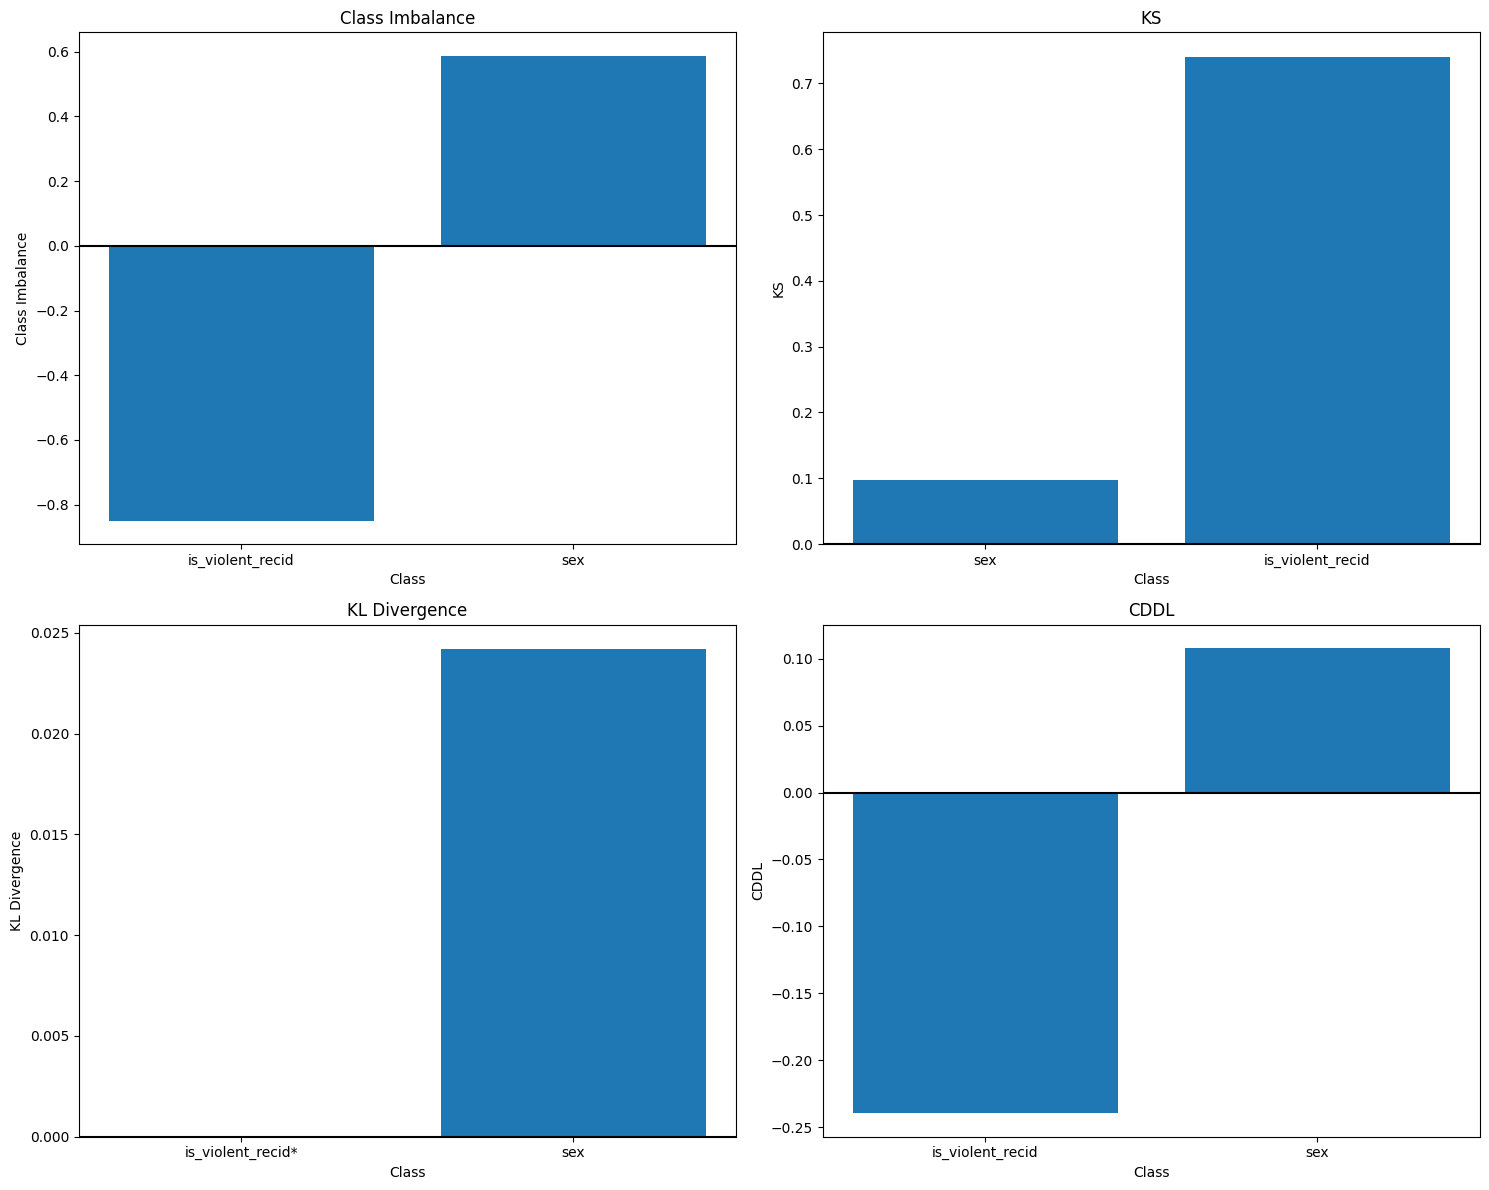

In [20]:
h.get_metrics_graph(metrics, plt)